In [1]:
#RMF Scoring and Segmentation for Meesho Customers

import numpy as np
import pandas as pd

# Load views or flat CSV
df_c360 = pd.read_csv('meesho_customers.csv')
df_orders = pd.read_csv('meesho_orders.csv')

# Merge and calculate R, F, M
df_orders['Order_Date'] = pd.to_datetime(df_orders['Order_Date'])
max_date = df_orders['Order_Date'].max() + pd.Timedelta(days=1)

rfm = (
    df_orders.groupby('Customer_ID')
    .agg(
        Recency=('Order_Date', lambda x: (max_date - x.max()).days),
        Frequency=('Order_ID', 'nunique'),
        Monetary=('Total_Amount', 'sum'),
    )
    .reset_index()
)

# R, F, M Quintile Scoring
rfm['R_Score'] = pd.qcut(
    rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]
)  # Lower recency = better score
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]
)
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5]
)


# Segment Assignment Rules
def segment_customer(df):
    if df['R_Score'] >= 4 and df['F_Score'] >= 4:
        return 'Champion'
    elif df['F_Score'] >= 3 and df['M_Score'] >= 3:
        return 'Loyal Customer'
    elif df['R_Score'] >= 4 and df['F_Score'] <= 2:
        return 'New Potential'
    elif df['R_Score'] <= 2 and df['F_Score'] >= 3:
        return 'At Risk'
    else:
        return 'Lost / Hibernating'


rfm['Customer_Segment'] = rfm.apply(segment_customer, axis=1)
rfm.to_csv('rfm_customer_segments.csv', index=False)
print(rfm['Customer_Segment'].value_counts())

Customer_Segment
Lost / Hibernating    3338
Loyal Customer        3001
Champion              2154
New Potential         1092
At Risk                348
Name: count, dtype: int64


In [2]:
# Cohort Analysis
df_orders['OrderMonth'] = df_orders['Order_Date'].dt.to_period('M')
df_orders['CohortMonth'] = (
    df_orders.groupby('Customer_ID')['Order_Date']
    .transform('min')
    .dt.to_period('M')
)


def get_cohort_index(df):
    year_diff = df['OrderMonth'].dt.year - df['CohortMonth'].dt.year
    month_diff = df['OrderMonth'].dt.month - df['CohortMonth'].dt.month
    return year_diff * 12 + month_diff + 1


df_orders['CohortIndex'] = get_cohort_index(df_orders)

cohort_data = (
    df_orders.groupby(['CohortMonth', 'CohortIndex'])['Customer_ID']
    .nunique()
    .reset_index()
)
cohort_pivot = cohort_data.pivot(
    index='CohortMonth', columns='CohortIndex', values='Customer_ID'
)

# Retention Rate Matrix
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100
retention_matrix.to_csv('cohort_retention_matrix.csv')

Cohort Size (Base Customers per Cohort):
CohortMonth
2025-01    3428.0
2025-02    2119.0
2025-03    1564.0
2025-04    1003.0
2025-05     664.0
2025-06     420.0
2025-07     265.0
2025-08     171.0
2025-09     111.0
2025-10      87.0
2025-11      60.0
2025-12      41.0
Freq: M, Name: 1, dtype: float64

First 5 Rows of Retention Matrix (%):
CohortIndex     1     2     3     4     5     6     7     8     9     10  \
CohortMonth                                                                
2025-01      100.0  31.7  34.9  33.1  35.6  32.6  34.5  34.7  33.1  32.7   
2025-02      100.0  34.8  33.5  35.1  33.2  35.6  35.0  33.5  34.5  35.0   
2025-03      100.0  33.6  34.5  34.0  33.7  35.4  35.0  34.8  34.8  35.9   
2025-04      100.0  34.4  31.4  34.5  34.7  32.6  34.2  33.9  35.2   1.5   
2025-05      100.0  33.3  37.5  34.0  32.7  33.0  33.7  33.6   1.7   NaN   

CohortIndex    11    12   13  
CohortMonth                   
2025-01      33.9  34.4  1.7  
2025-02      35.1   1.1  NaN  
20

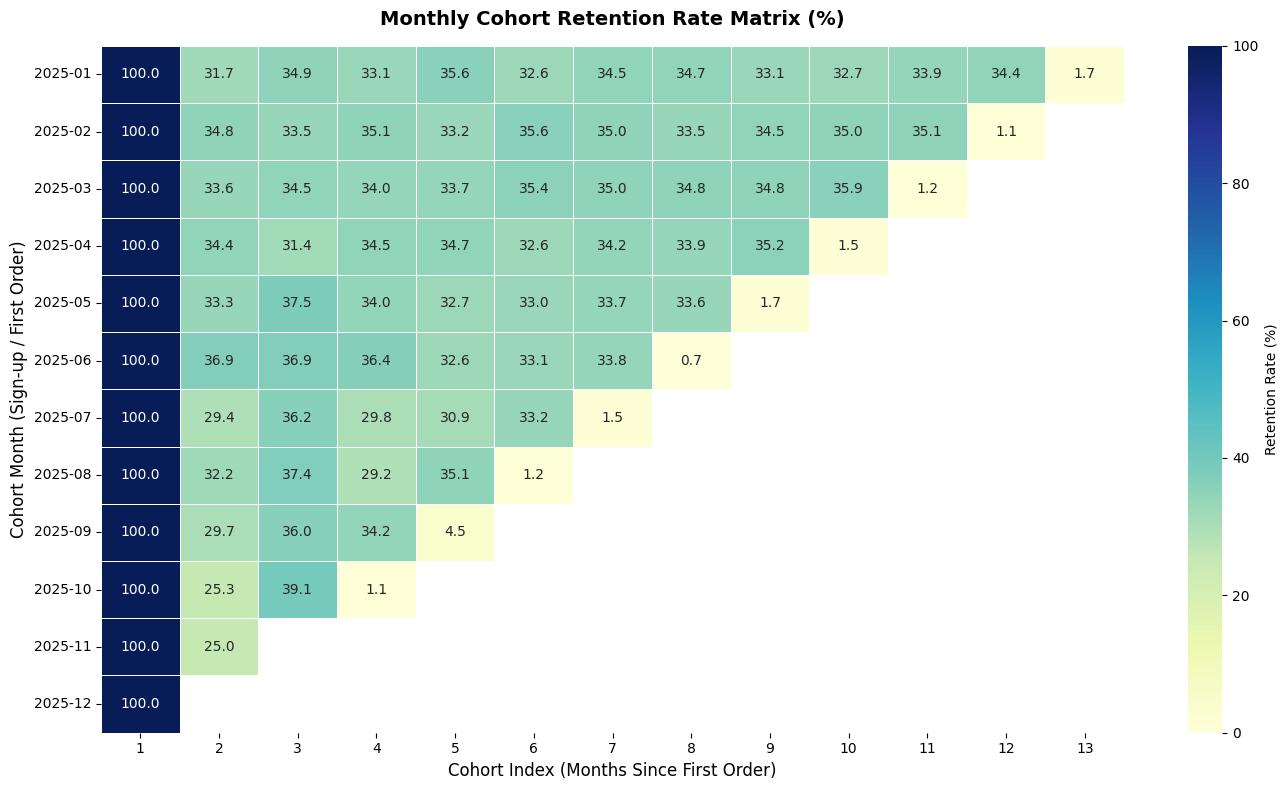

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_orders = pd.read_csv('meesho_orders.csv')

# Ensure datetime
df_orders['Order_Date'] = pd.to_datetime(df_orders['Order_Date'])

# Cohort calculations
df_orders['OrderMonth'] = df_orders['Order_Date'].dt.to_period('M')
df_orders['CohortMonth'] = (
    df_orders.groupby('Customer_ID')['Order_Date']
    .transform('min')
    .dt.to_period('M')
)

def get_cohort_index(df):
    year_diff = df['OrderMonth'].dt.year - df['CohortMonth'].dt.year
    month_diff = df['OrderMonth'].dt.month - df['CohortMonth'].dt.month
    return year_diff * 12 + month_diff + 1

df_orders['CohortIndex'] = get_cohort_index(df_orders)

cohort_data = (
    df_orders.groupby(['CohortMonth', 'CohortIndex'])['Customer_ID']
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_data.pivot(
    index='CohortMonth', columns='CohortIndex', values='Customer_ID'
)

# Retention Rate Matrix
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100
retention_matrix.to_csv('cohort_retention_matrix.csv')

print("Cohort Size (Base Customers per Cohort):")
print(cohort_size)
print("\nFirst 5 Rows of Retention Matrix (%):")
print(retention_matrix.round(1).head())

# Plot Heatmaps
plt.figure(figsize=(14, 8))

# Heatmap 1: Retention Percentage
plt.subplot(1, 1, 1)
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Retention Rate (%)'},
    linewidths=0.5,
    vmin=0,
    vmax=100
)
plt.title('Monthly Cohort Retention Rate Matrix (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cohort Index (Months Since First Order)', fontsize=12)
plt.ylabel('Cohort Month (Sign-up / First Order)', fontsize=12)
plt.tight_layout()

plt.savefig('cohort_retention_heatmap.png', dpi=300)
plt.show()

--- COHORT RETENTION MATRIX (%) ---
CohortIndex     1     2     3     4     5     6     7     8     9     10  \
CohortMonth                                                                
2025-01      100.0  31.7  34.9  33.1  35.6  32.6  34.5  34.7  33.1  32.7   
2025-02      100.0  34.8  33.5  35.1  33.2  35.6  35.0  33.5  34.5  35.0   
2025-03      100.0  33.6  34.5  34.0  33.7  35.4  35.0  34.8  34.8  35.9   
2025-04      100.0  34.4  31.4  34.5  34.7  32.6  34.2  33.9  35.2   1.5   
2025-05      100.0  33.3  37.5  34.0  32.7  33.0  33.7  33.6   1.7   NaN   
2025-06      100.0  36.9  36.9  36.4  32.6  33.1  33.8   0.7   NaN   NaN   
2025-07      100.0  29.4  36.2  29.8  30.9  33.2   1.5   NaN   NaN   NaN   
2025-08      100.0  32.2  37.4  29.2  35.1   1.2   NaN   NaN   NaN   NaN   
2025-09      100.0  29.7  36.0  34.2   4.5   NaN   NaN   NaN   NaN   NaN   
2025-10      100.0  25.3  39.1   1.1   NaN   NaN   NaN   NaN   NaN   NaN   
2025-11      100.0  25.0   NaN   NaN   NaN   NaN   N

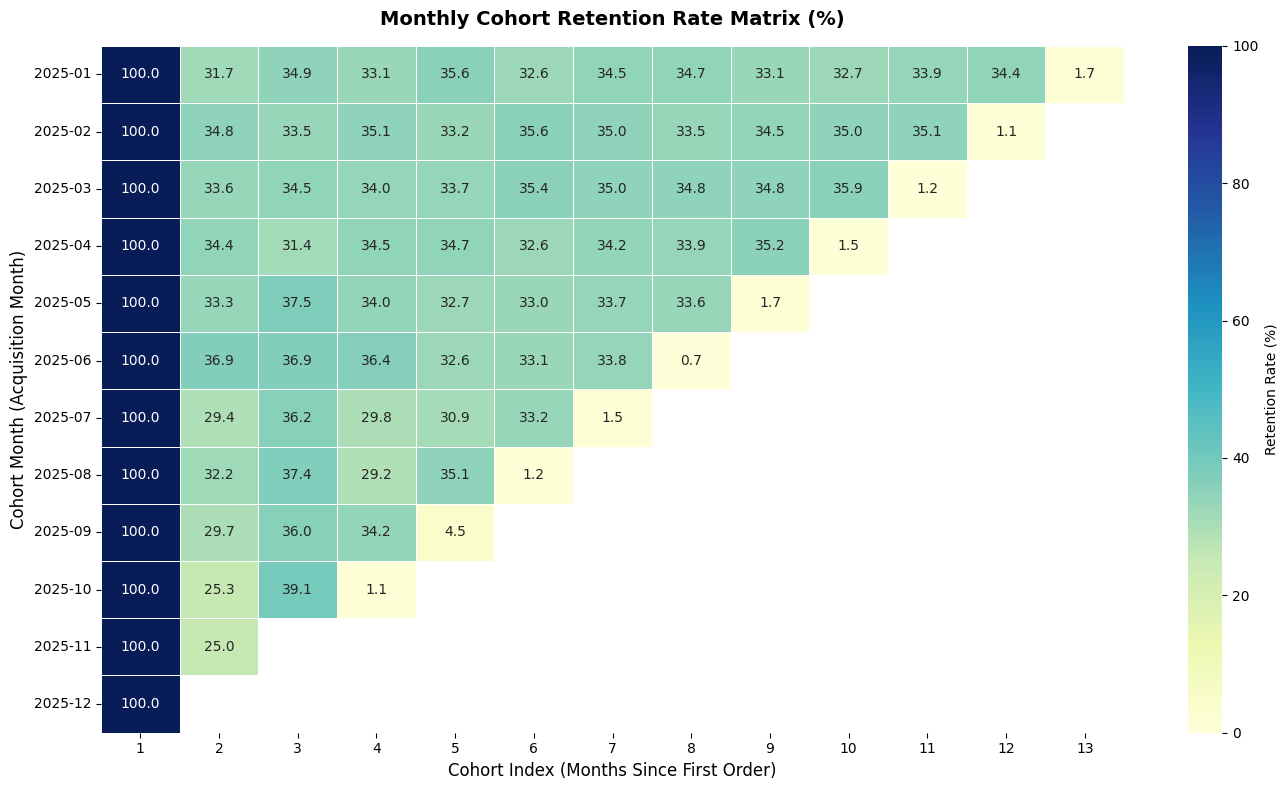

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df_orders = pd.read_csv('meesho_orders.csv')
df_orders['Order_Date'] = pd.to_datetime(df_orders['Order_Date'])

# 2. Assign Cohort Month and Order Month
df_orders['OrderMonth'] = df_orders['Order_Date'].dt.to_period('M')
df_orders['CohortMonth'] = (
    df_orders.groupby('Customer_ID')['Order_Date']
    .transform('min')
    .dt.to_period('M')
)

# 3. Calculate Cohort Index (Months elapsed since acquisition)
def get_cohort_index(df):
    year_diff = df['OrderMonth'].dt.year - df['CohortMonth'].dt.year
    month_diff = df['OrderMonth'].dt.month - df['CohortMonth'].dt.month
    return year_diff * 12 + month_diff + 1

df_orders['CohortIndex'] = get_cohort_index(df_orders)

# 4. Create Cohort Counts Matrix
cohort_data = (
    df_orders.groupby(['CohortMonth', 'CohortIndex'])['Customer_ID']
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_data.pivot(
    index='CohortMonth', columns='CohortIndex', values='Customer_ID'
)

# 5. Calculate Retention Rate Matrix (%)
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

# Export to CSV
retention_matrix.to_csv('cohort_retention_matrix.csv')

# 6. Print Summary Matrix to Console
print("--- COHORT RETENTION MATRIX (%) ---")
print(retention_matrix.round(1))

# 7. Plot Heatmap Visualization
plt.figure(figsize=(14, 8))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Retention Rate (%)'},
    linewidths=0.5,
    vmin=0,
    vmax=100
)

plt.title('Monthly Cohort Retention Rate Matrix (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cohort Index (Months Since First Order)', fontsize=12)
plt.ylabel('Cohort Month (Acquisition Month)', fontsize=12)
plt.tight_layout()

# Save image for Power BI / Portfolio display
plt.savefig('cohort_retention_heatmap.png', dpi=300)
plt.show()